# Stock Price Prediction using LSTM and GRU

## Project Overview

Time series forecasting is one of the most common applications of sequential deep learning models. In this project, we use **Long Short-Term Memory (LSTM)** and **Gated Recurrent Unit (GRU)** networks to predict future stock prices based on historical market data.

The project follows a complete machine learning workflow, including data acquisition, preprocessing, feature scaling, sequence generation, model training, evaluation, and visualization.

## Objectives

- Download historical stock market data.
- Perform exploratory data analysis (EDA).
- Prepare multivariate time-series data.
- Build and train an LSTM model.
- Build and train a GRU model.
- Compare both models using regression metrics.
- Visualize predicted versus actual stock prices.

## Step 1 — Import Libraries

In [1]:
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import yfinance as yf

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

2026-07-22 01:35:20.416345: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-22 01:35:20.821247: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1784709320.967980    4391 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1784709321.008018    4391 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1784709321.297448    4391 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## Step 2 — Verify TensorFlow

In [2]:
print("TensorFlow Version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("GPU:", gpus[0].name)
else:
    print("Running on CPU")

TensorFlow Version: 2.19.0
GPU: /physical_device:GPU:0


## Step 3 — Download the Dataset

In [3]:
ticker = "AAPL"

df = yf.download(
    ticker,
    start="2015-01-01",
    end="2025-01-01"
)

df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.192602,24.659504,23.754466,24.648440,212818400
2015-01-05,23.511055,24.042129,23.325180,23.962467,257142000
2015-01-06,23.513275,23.772173,23.152587,23.575233,263188400
2015-01-07,23.842979,23.942555,23.610634,23.721274,160423600
2015-01-08,24.759083,24.816616,24.053197,24.170477,237458000


## Step 4 — Inspect the Dataset

In [4]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2516 entries, 2015-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   2516 non-null   float64
 1   (High, AAPL)    2516 non-null   float64
 2   (Low, AAPL)     2516 non-null   float64
 3   (Open, AAPL)    2516 non-null   float64
 4   (Volume, AAPL)  2516 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 117.9 KB


In [5]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,2516.000000,2516.000000,2516.000000,2516.000000,2.516000e+03
mean,93.684878,94.594694,92.673089,93.598213,1.170853e+08
std,65.319932,65.912255,64.634535,65.239868,6.839614e+07
min,20.565870,20.868639,20.367816,20.488465,2.323470e+07
25%,35.157632,35.554812,34.780268,35.177796,7.105610e+07
50%,64.268631,64.822327,63.468161,64.109460,1.003646e+08
75%,149.955402,151.700211,147.992755,149.778504,1.426216e+08
max,257.375580,258.448740,255.994420,256.550862,6.488252e+08


In [6]:
df.isnull().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

## Step 5 — Display the First Few Rows

In [7]:
df.head(10)

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.192602,24.659504,23.754466,24.648440,212818400
2015-01-05,23.511055,24.042129,23.325180,23.962467,257142000
2015-01-06,23.513275,23.772173,23.152587,23.575233,263188400
2015-01-07,23.842979,23.942555,23.610634,23.721274,160423600
2015-01-08,24.759083,24.816616,24.053197,24.170477,237458000
2015-01-09,24.785643,25.060030,24.387337,24.931687,214798000
2015-01-12,24.174896,24.922824,24.075321,24.916186,198603200
2015-01-13,24.389544,24.960448,24.099667,24.657293,268367600


## Step 6 — Explore the Dataset

**Exploratory Data Analysis (EDA)**

Before training any deep learning models, it is important to understand the dataset.

In this section, we will:

- Examine the stock price over time.
- Analyze the distribution of numerical features.
- Explore correlations between features.
- Check for missing values and anomalies.

These insights help us better understand the data and guide our preprocessing decisions.

## Step 7 — Closing Price Over Time

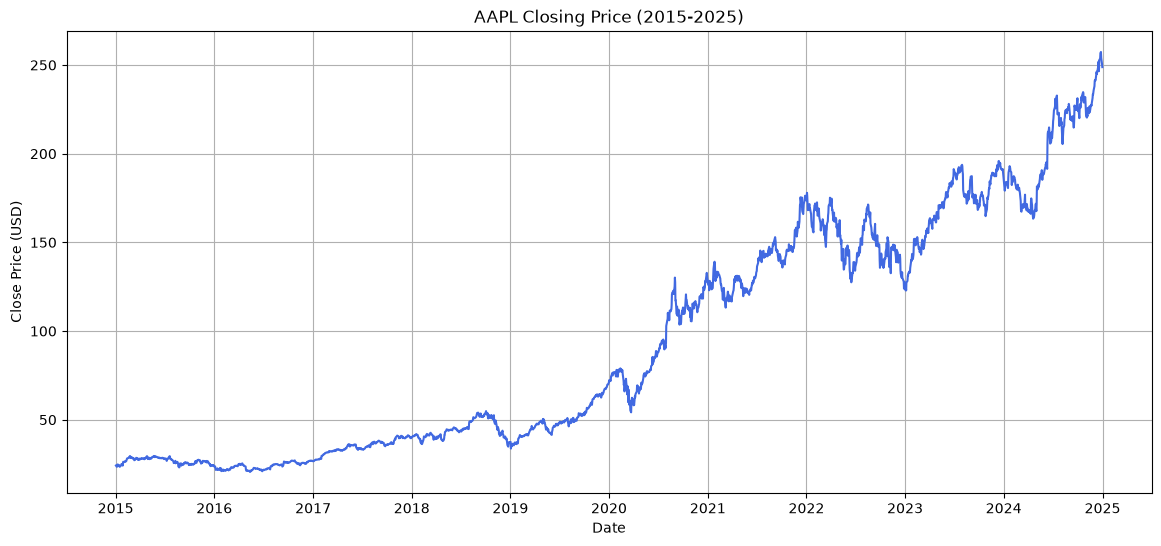

In [8]:
plt.figure(figsize=(14,6))

plt.plot(df.index, df["Close"], color="royalblue")

plt.title(f"{ticker} Closing Price (2015-2025)")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")

plt.grid(True)

plt.show()

## Step 8 — Trading Volume

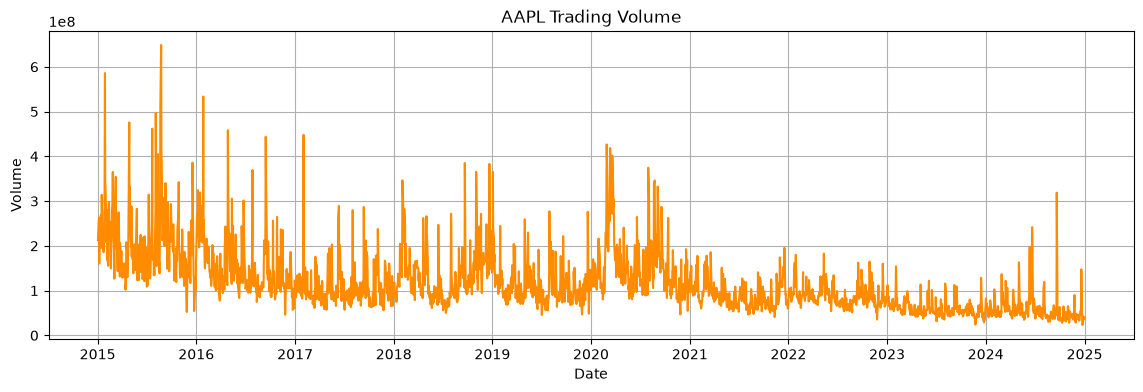

In [9]:
plt.figure(figsize=(14,4))

plt.plot(df.index, df["Volume"], color="darkorange")

plt.title(f"{ticker} Trading Volume")

plt.xlabel("Date")
plt.ylabel("Volume")

plt.grid(True)

plt.show()

## Step 9 — Distribution of Features

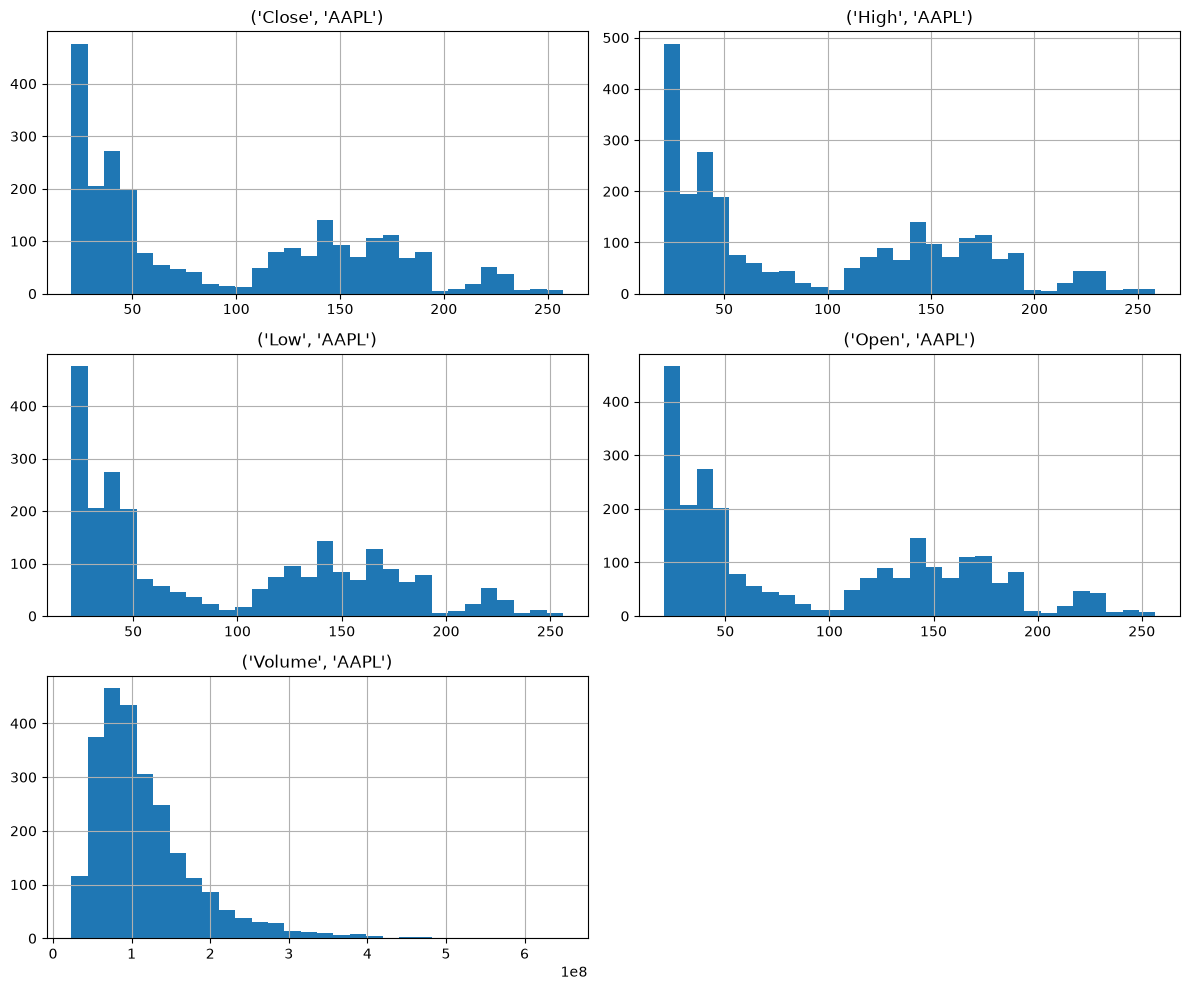

In [10]:
df.hist(
    figsize=(12,10),
    bins=30
)

plt.tight_layout()

plt.show()

## Step 11 — Correlation Matrix

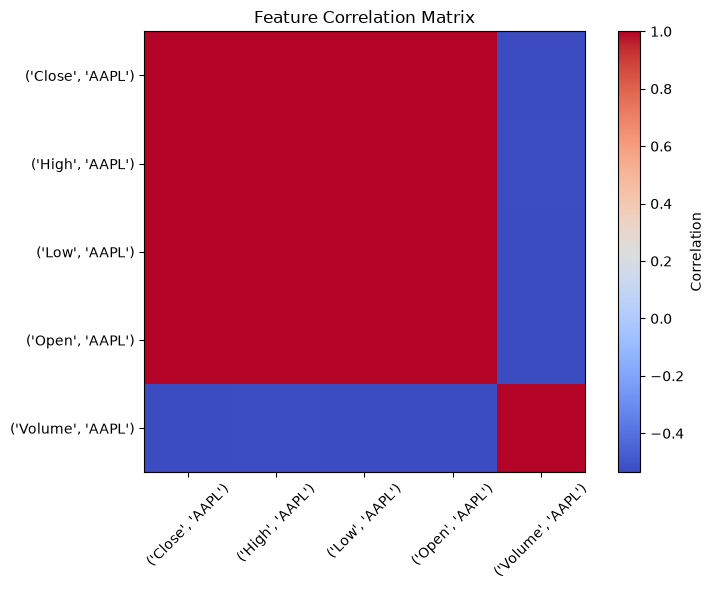

In [11]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))

plt.imshow(corr, cmap="coolwarm")

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.colorbar(label="Correlation")

plt.title("Feature Correlation Matrix")

plt.tight_layout()

plt.show()

## Step 11 — Pairwise Correlations

In [12]:
corr[("Close", "AAPL")].sort_values(ascending=False)

Price   Ticker
Close   AAPL      1.000000
High    AAPL      0.999867
Low     AAPL      0.999866
Open    AAPL      0.999714
Volume  AAPL     -0.532486
Name: (Close, AAPL), dtype: float64

## Step 12 — Feature Selection

**Feature Selection**

The dataset contains several market indicators.

For this project, we use:

- Open
- High
- Low
- Close
- Volume

These features provide information about each trading day and are commonly used in stock price forecasting.

Our target variable will be the **Close** price of the next trading day.

In [13]:
features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume"
]

data = df[features]

data.head()

Price,Open,High,Low,Close,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.648440,24.659504,23.754466,24.192602,212818400
2015-01-05,23.962467,24.042129,23.325180,23.511055,257142000
2015-01-06,23.575233,23.772173,23.152587,23.513275,263188400
2015-01-07,23.721274,23.942555,23.610634,23.842979,160423600
2015-01-08,24.170477,24.816616,24.053197,24.759083,237458000


## Step 13 — Feature Scaling

Deep learning models perform better when input features have similar numerical ranges.

We use Min-Max normalization to scale each feature between 0 and 1.

The scaler will later be used to transform predictions back to their original values.

In [14]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

scaled_data = pd.DataFrame(
    scaled_data,
    columns=features,
    index=data.index
)

scaled_data.head()

,Open,High,Low,Close,Volume
Date,,,,,
2015-01-02,0.017622,0.015956,0.014373,0.015315,0.303048
2015-01-05,0.014716,0.013358,0.012551,0.012437,0.373898
2015-01-06,0.013076,0.012221,0.011819,0.012446,0.383564
2015-01-07,0.013695,0.012938,0.013763,0.013839,0.219295
2015-01-08,0.015598,0.016617,0.015641,0.017707,0.342434


## Step 14 — Visualize Scaled Data

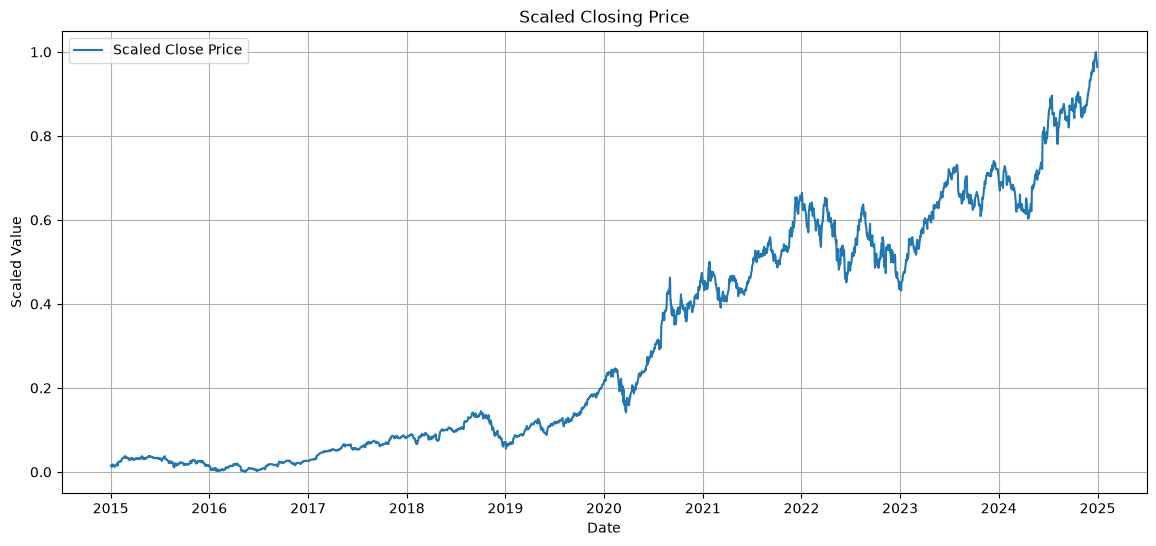

In [15]:
plt.figure(figsize=(14,6))

plt.plot(
    scaled_data["Close"],
    label="Scaled Close Price"
)

plt.title("Scaled Closing Price")

plt.xlabel("Date")
plt.ylabel("Scaled Value")

plt.legend()

plt.grid(True)

plt.show()

## Step 15 — Create Sliding Windows

**Create Input Sequences**

LSTM and GRU models cannot learn directly from a continuous time series. Instead, the data must be divided into overlapping sequences using a **sliding window**.

In this project, each input sequence contains the market data from the **previous 60 trading days**, and the model learns to predict the **closing price of the next trading day**.

This transforms the forecasting problem into a supervised learning task.

In [16]:
WINDOW_SIZE = 60

## Step 16 — Create Sequences

In [17]:
def create_sequences(data, window_size):
    X = []
    y = []

    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size, 3])  # Close column

    return np.array(X), np.array(y)

## Step 17 — Generate the Dataset

In [18]:
X, y = create_sequences(
    scaled_data.values,
    WINDOW_SIZE
)

print("Input shape :", X.shape)
print("Target shape:", y.shape)

Input shape : (2456, 60, 5)
Target shape: (2456,)


## Step 18 — Train/Test Split

Unlike many machine learning tasks, time-series data must **not be shuffled** before splitting.

Shuffling would allow the model to learn from future observations, leading to unrealistic performance estimates.

Instead, we preserve the chronological order by using the earliest observations for training and the most recent observations for testing.

In [19]:
split_index = int(len(X) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

**Verify Shapes:**

In [20]:
print("Training Input :", X_train.shape)
print("Testing Input  :", X_test.shape)

print("Training Target:", y_train.shape)
print("Testing Target :", y_test.shape)

Training Input : (1964, 60, 5)
Testing Input  : (492, 60, 5)
Training Target: (1964,)
Testing Target : (492,)


## Step 19 — Build the LSTM Model

We construct an LSTM-based neural network to learn temporal dependencies in the stock market data.

The architecture consists of:

- An input layer that accepts sequences of 60 trading days.
- Two stacked LSTM layers to capture both short-term and long-term temporal patterns.
- Dropout layers to reduce overfitting.
- A dense hidden layer for nonlinear feature learning.
- A single output neuron to predict the next day's closing price.

In [21]:
lstm_model = Sequential([
    Input(shape=(WINDOW_SIZE, len(features))),

    LSTM(64, return_sequences=True),
    Dropout(0.2),

    LSTM(32),
    Dropout(0.2),

    Dense(16, activation="relu"),
    Dense(1)
])

lstm_model.summary()

I0000 00:00:1784709335.973548    4391 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1414 MB memory:  -> device: 0, name: NVIDIA GeForce MX330, pci bus id: 0000:01:00.0, compute capability: 6.1


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,881 (120.63 KB)

 Trainable params: 30,881 (120.63 KB)

 Non-trainable params: 0 (0.00 B)

## Step 20 — Compile the Model

Since stock price prediction is a regression task, we use:

- **Optimizer:** Adam
- **Loss Function:** Mean Squared Error (MSE)
- **Metric:** Mean Absolute Error (MAE)

In [22]:
lstm_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

## Step 21 — Train the Model

In [23]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [24]:
history = lstm_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1,
    callbacks=[early_stop]
)

Epoch 1/30


I0000 00:00:1784709338.432217    4450 cuda_dnn.cc:529] Loaded cuDNN version 90300


50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0036 - mae: 0.0367 - val_loss: 0.0037 - val_mae: 0.0536
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 6.2077e-04 - mae: 0.0149 - val_loss: 8.8258e-04 - val_mae: 0.0240
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 6.1303e-04 - mae: 0.0155 - val_loss: 8.5882e-04 - val_mae: 0.0236
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 4.7938e-04 - mae: 0.0132 - val_loss: 8.9262e-04 - val_mae: 0.0239
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 5.1763e-04 - mae: 0.0140 - val_loss: 8.6258e-04 - val_mae: 0.0238
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 4.6296e-04 - mae: 0.0128 - val_loss: 7.2458e-04 - val_mae: 0.0216
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 3.8267e-04 - mae: 0.0122 - val_loss: 8.5860e-04 - val_mae: 0.0232
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 4.1209e-04 - mae: 0.0121 - val_loss: 0.0013 - val_mae: 0.0302
Epoch 9/30
50/50 ━━━━━━

## Step 22 — Visualize Training History

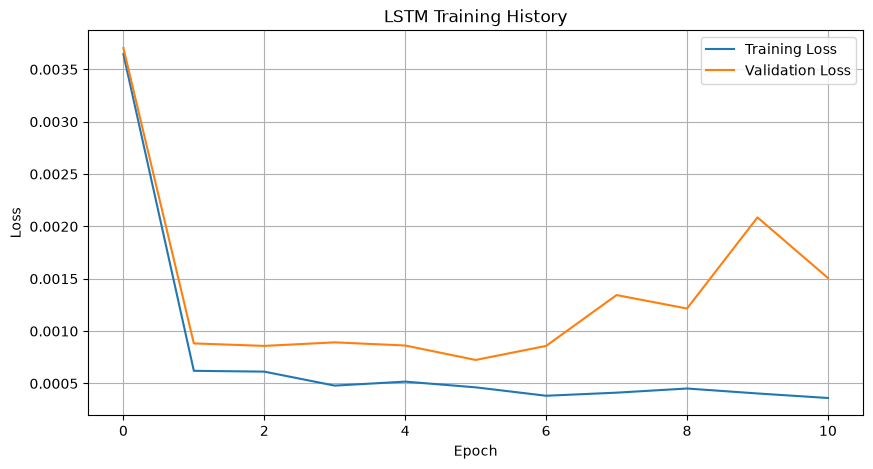

In [25]:
plt.figure(figsize=(10,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("LSTM Training History")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

## Step 23 — Generate Predictions

In [26]:
y_pred_scaled = lstm_model.predict(X_test)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


## Step 24 — Inverse Transform Predictions

Our MinMaxScaler was fitted on **five features**, but the model predicts only the **Close** price. The scaler expects the same number of features during inverse_transform(), so we'll create temporary arrays, place the scaled Close values in the correct column, perform the inverse transformation, and then extract the Close column.

In [27]:
temp_pred = np.zeros((len(y_pred_scaled), len(features)))
temp_actual = np.zeros((len(y_test), len(features)))

# Close price is the fourth feature (index 3)
temp_pred[:, 3] = y_pred_scaled.flatten()
temp_actual[:, 3] = y_test

predictions = scaler.inverse_transform(temp_pred)[:, 3]
actual = scaler.inverse_transform(temp_actual)[:, 3]

## Step 25 — Evaluate the LSTM

In [28]:
mse = mean_squared_error(actual, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actual, predictions)
r2 = r2_score(actual, predictions)

print(f"MSE :  {mse:.4f}")
print(f"RMSE:  {rmse:.4f}")
print(f"MAE :  {mae:.4f}")
print(f"R²  :  {r2:.4f}")

MSE :  221.4138
RMSE:  14.8800
MAE :  11.1988
R²  :  0.6958


## Step 27 — Plot Actual vs. Predicted Prices

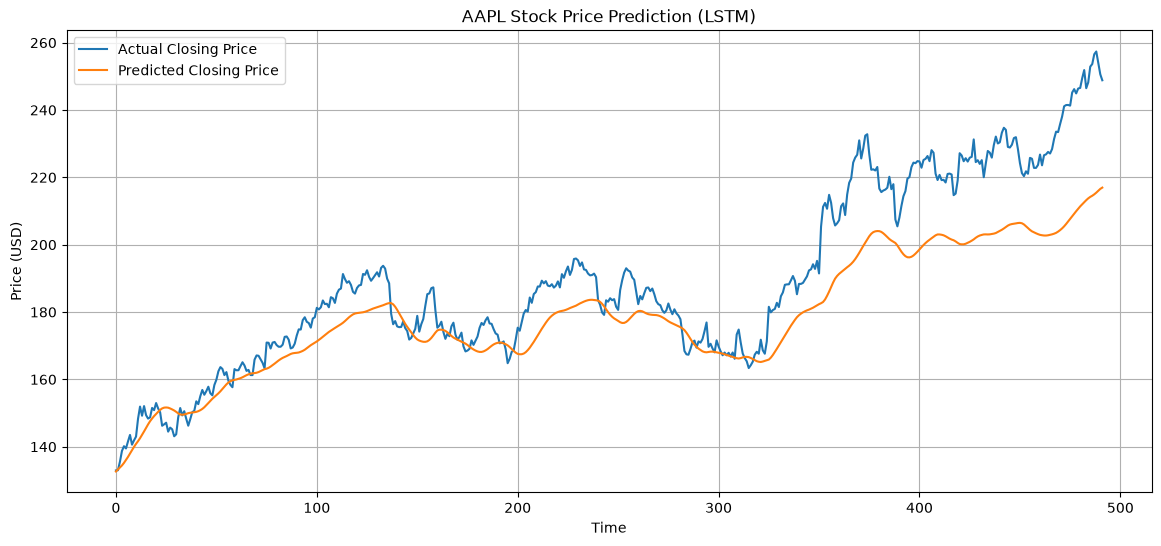

In [29]:
plt.figure(figsize=(14,6))

plt.plot(actual, label="Actual Closing Price")
plt.plot(predictions, label="Predicted Closing Price")

plt.title(f"{ticker} Stock Price Prediction (LSTM)")
plt.xlabel("Time")
plt.ylabel("Price (USD)")

plt.legend()
plt.grid(True)

plt.show()

## Step 27 — Build the GRU Model

To compare recurrent architectures fairly, we construct a GRU model with the same overall architecture as the LSTM model.

The only difference is that the LSTM layers are replaced with GRU layers.

This allows us to compare the two models based on:
- Prediction accuracy
- Error metrics
- Training behavior

In [30]:
gru_model = Sequential([
    Input(shape=(WINDOW_SIZE, len(features))),

    GRU(64, return_sequences=True),
    Dropout(0.2),

    GRU(32),
    Dropout(0.2),

    Dense(16, activation="relu"),
    Dense(1)
])

gru_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 60, 64)         │        13,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,585 (92.13 KB)

 Trainable params: 23,585 (92.13 KB)

 Non-trainable params: 0 (0.00 B)

## Step 28 — Compile the GRU Model

In [31]:
gru_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

## Step 29 — Train the GRU Model

In [32]:
gru_history = gru_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1,
    callbacks=[early_stop]
)

Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0037 - mae: 0.0381 - val_loss: 5.0574e-04 - val_mae: 0.0179
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 7.3440e-04 - mae: 0.0174 - val_loss: 9.0341e-04 - val_mae: 0.0249
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 5.0102e-04 - mae: 0.0138 - val_loss: 0.0015 - val_mae: 0.0338
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 4.8589e-04 - mae: 0.0137 - val_loss: 0.0016 - val_mae: 0.0349
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 4.6200e-04 - mae: 0.0130 - val_loss: 3.8156e-04 - val_mae: 0.0155
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 4.1014e-04 - mae: 0.0124 - val_loss: 5.7878e-04 - val_mae: 0.0197
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 4.0987e-04 - mae: 0.0123 - val_loss: 3.8323e-04 - val_mae: 0.0157
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 3.9913e-04 - mae: 0.0124 - val_loss: 0.0017 - val_mae: 0.0375
Epoch 9/30
50/50

## Step 30 — Plot Training History

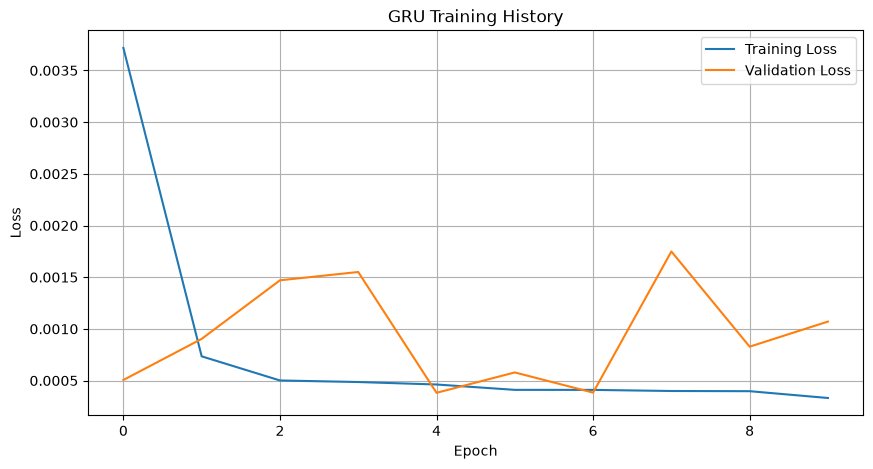

In [33]:
plt.figure(figsize=(10,5))

plt.plot(gru_history.history["loss"], label="Training Loss")
plt.plot(gru_history.history["val_loss"], label="Validation Loss")

plt.title("GRU Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

## Step 31 — Generate Predictions

In [34]:
gru_pred_scaled = gru_model.predict(X_test)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


## Step 32 — Inverse Transform Predictions

In [35]:
temp_pred = np.zeros((len(gru_pred_scaled), len(features)))
temp_pred[:, 3] = gru_pred_scaled.flatten()

gru_predictions = scaler.inverse_transform(temp_pred)[:, 3]

## Step 33 — Evaluate the GRU Model

In [36]:
gru_mse = mean_squared_error(actual, gru_predictions)
gru_rmse = np.sqrt(gru_mse)
gru_mae = mean_absolute_error(actual, gru_predictions)
gru_r2 = r2_score(actual, gru_predictions)

print(f"MSE :  {gru_mse:.4f}")
print(f"RMSE:  {gru_rmse:.4f}")
print(f"MAE :  {gru_mae:.4f}")
print(f"R²  :  {gru_r2:.4f}")

MSE :  31.7265
RMSE:  5.6326
MAE :  4.3634
R²  :  0.9564


## Step 34 — Plot Actual vs. GRU Predictions

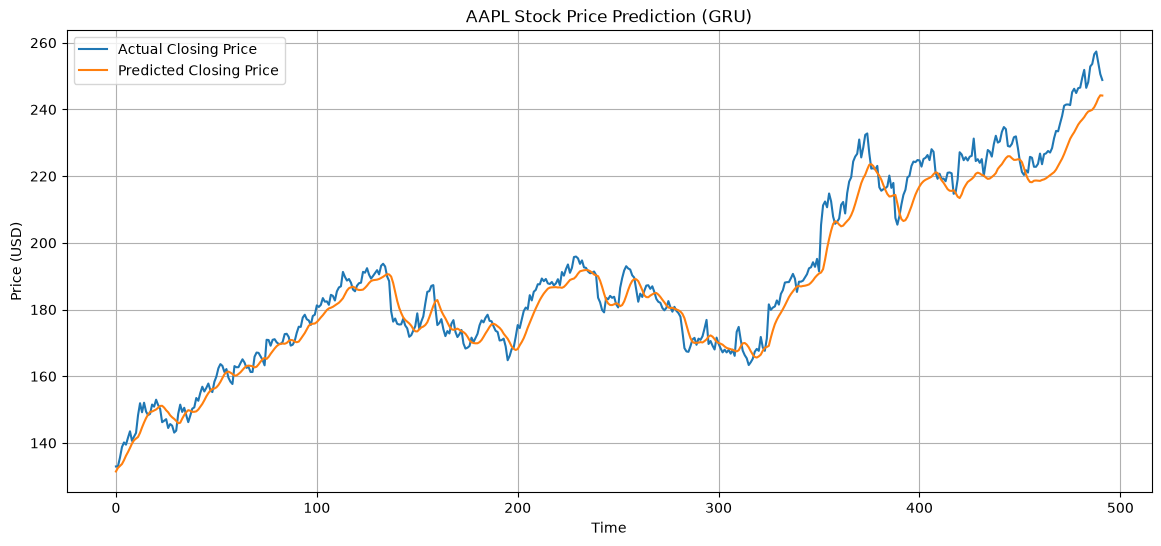

In [37]:
plt.figure(figsize=(14,6))

plt.plot(actual, label="Actual Closing Price")
plt.plot(gru_predictions, label="Predicted Closing Price")

plt.title(f"{ticker} Stock Price Prediction (GRU)")
plt.xlabel("Time")
plt.ylabel("Price (USD)")

plt.legend()
plt.grid(True)

plt.show()

## Step 35 — Compare LSTM and GRU

In [38]:
comparison = pd.DataFrame({
    "Model": ["LSTM", "GRU"],
    "MSE": [mse, gru_mse],
    "RMSE": [rmse, gru_rmse],
    "MAE": [mae, gru_mae],
    "R²": [r2, gru_r2]
})

comparison

,Model,MSE,RMSE,MAE,R²
0,LSTM,221.413782,14.879979,11.198759,0.695815
1,GRU,31.726492,5.632627,4.363378,0.956413


## Step 36 — Visual Comparison

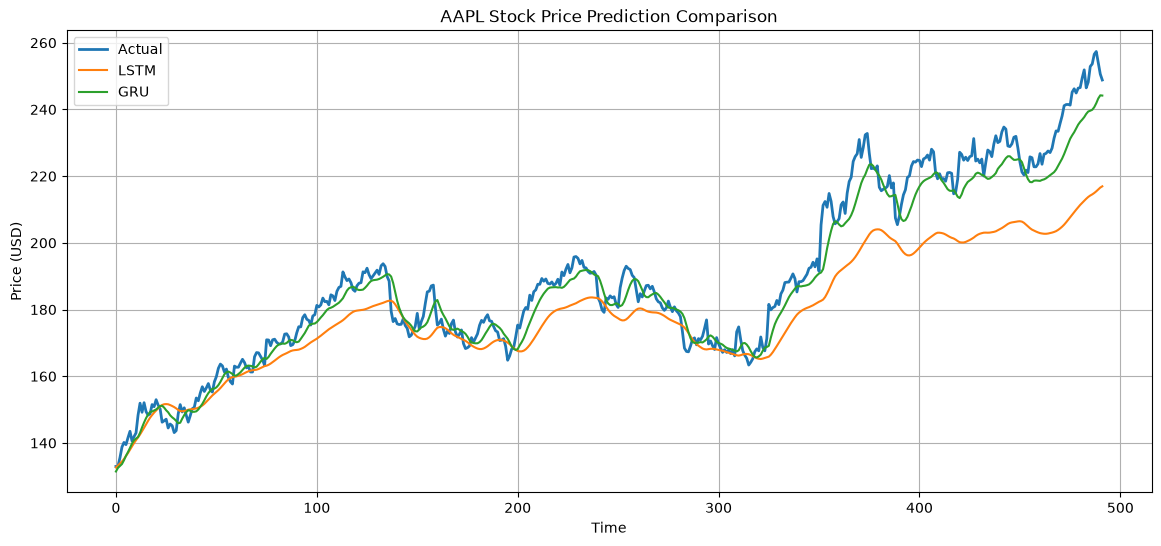

In [39]:
plt.figure(figsize=(14,6))

plt.plot(actual, label="Actual", linewidth=2)
plt.plot(predictions, label="LSTM")
plt.plot(gru_predictions, label="GRU")

plt.title(f"{ticker} Stock Price Prediction Comparison")
plt.xlabel("Time")
plt.ylabel("Price (USD)")

plt.legend()
plt.grid(True)

plt.show()